In [29]:
# Manejo de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

# Preprocesamiento (¡VITAL en no supervisado!)
from sklearn.preprocessing import StandardScaler

# Modelos de Clustering y PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Métricas y Dendrograma
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [30]:
df = pd.read_csv("datasets/student_performance_data.csv")
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [31]:
df.isnull().sum()

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  str    
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  str    
 9   extra_classes          10000 non-null  str    
 10  parent_education       10000 non-null  str    
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  str    
dtypes: float64(8), int64(1), str(5)
memory usage: 1.1 MB


In [33]:
df.shape

(10000, 14)

observando las columnas borramos el student_id porque no nos aporta info, en cmabio grades si porque son las notas que sacan los estudiantes 

In [34]:
df_clean = df.drop(columns=["student_id"])


In [35]:
X_numeric = pd.get_dummies(df_clean, drop_first=True)
X_numeric.head()

,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score,gender_Male,internet_access_Yes,extra_classes_Yes,parent_education_High School,parent_education_Master,parent_education_PhD,grade_B,grade_C,grade_D,grade_F
0,4.54,69.98,36.47,70.70,53.10,17.96,8.09,52.3480,True,True,False,False,True,False,False,False,True,False
1,5.26,84.80,34.25,27.92,87.17,11.29,4.73,53.9485,False,False,True,False,False,False,False,False,True,False
2,8.69,73.76,72.29,70.92,99.61,76.10,8.73,82.0375,True,False,True,False,False,True,True,False,False,False
3,4.06,45.00,97.63,31.73,88.85,33.55,8.22,66.4110,True,False,False,False,False,False,False,True,False,False
4,8.83,51.13,65.19,78.28,54.23,88.99,8.59,65.6005,True,False,False,False,False,False,False,True,False,False


si no usamos el standarscaler nuestro algoritmo tomaria con mayor peso la feature de overall_score ya que presenta un desbalance de valores es decir outliers 

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)


-------

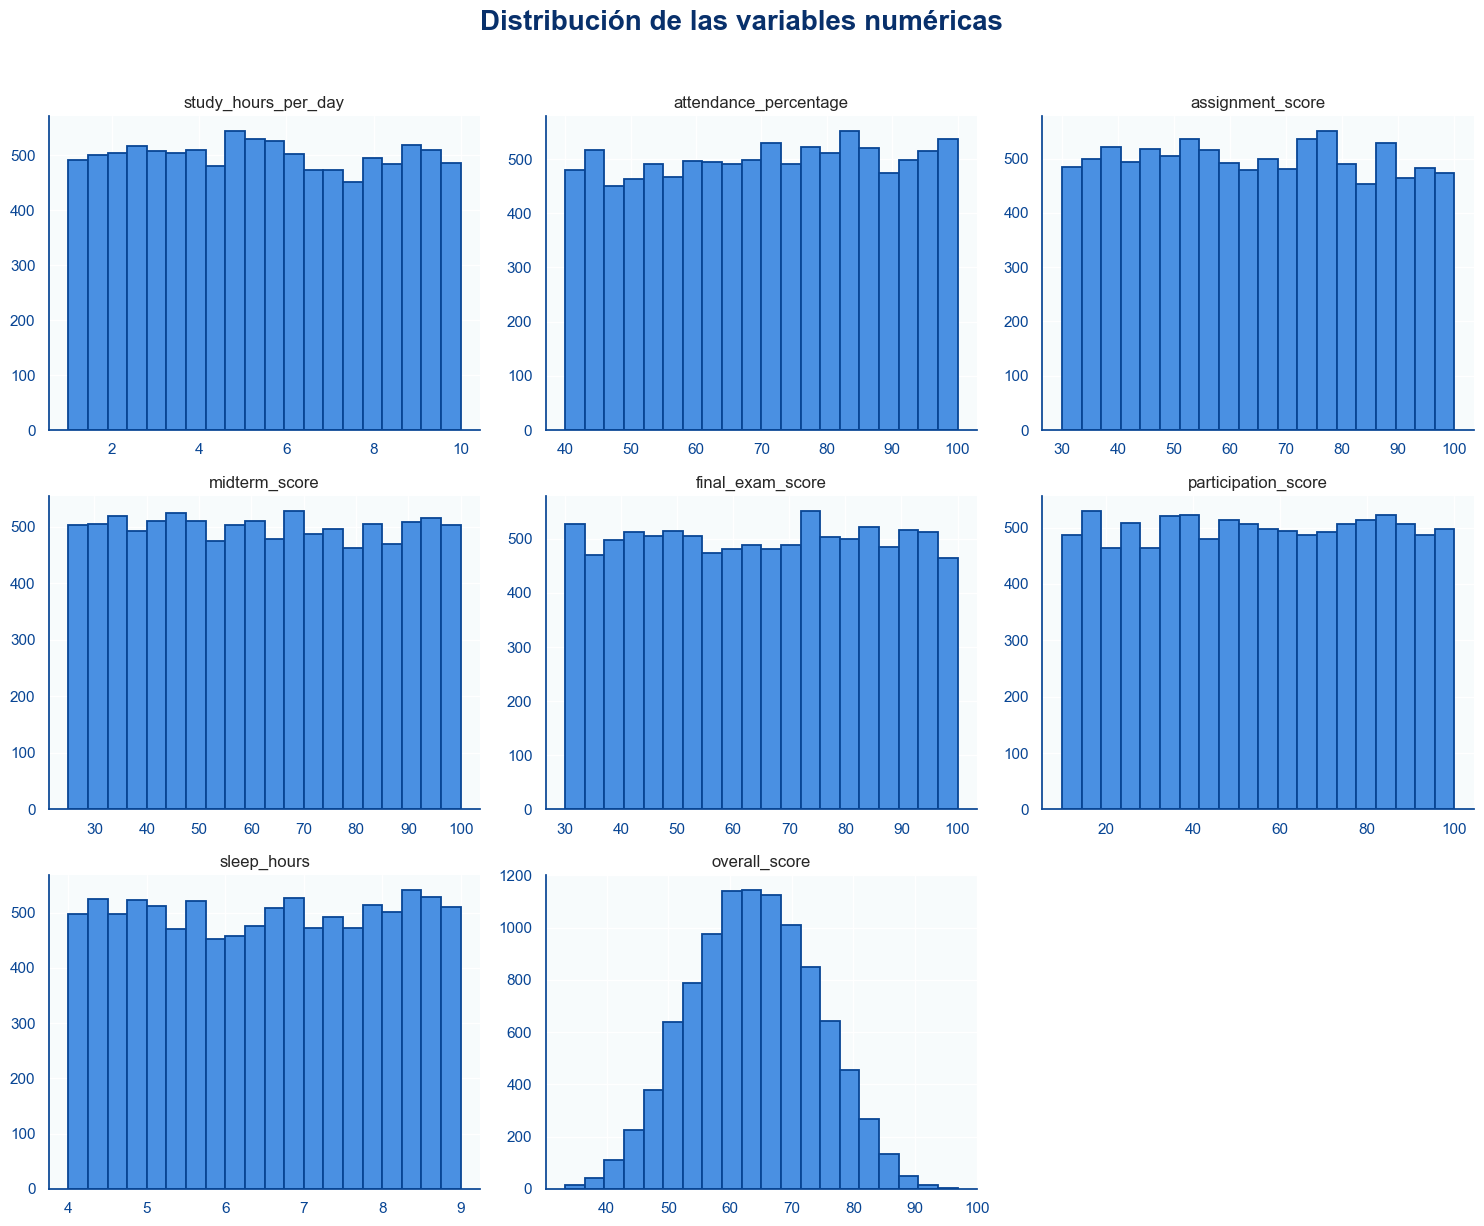

In [37]:
sns.set_theme(style="whitegrid")

color_barras = "#4a90e2"
color_borde = "#084594"

axes = df.drop('student_id', axis=1).hist(
    figsize=(15, 12),
    bins=20,
    color=color_barras,
    edgecolor=color_borde,
    linewidth=1.3
)

plt.suptitle(
    'Distribución de las variables numéricas', 
    fontsize=20, 
    fontweight='bold', 
    color='#08306b', 
    y=1.02
)

for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor('#f7fbfc')  # Fondo suave
        ax.grid(True, color='white', linewidth=1.0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#084594')
        ax.spines['bottom'].set_color('#084594')
        ax.tick_params(axis='x', colors='#084594')
        ax.tick_params(axis='y', colors='#084594')

plt.tight_layout()
plt.show()

----

In [38]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [39]:
X_pca.shape

(10000, 14)

In [40]:
pca.explained_variance_ratio_

array([0.1725694 , 0.09161388, 0.07443839, 0.07411262, 0.05941039,
       0.05817652, 0.05747035, 0.05596115, 0.05552161, 0.05544662,
       0.05519535, 0.05442192, 0.05295125, 0.05180963])

si le pongo que deje el 0.95 por ciento de la info realmetnbe no borra ninguna columna 

quedarse con dos componentes en este caso es muy erroneo se pierde demasiado informacion 

-----
k means

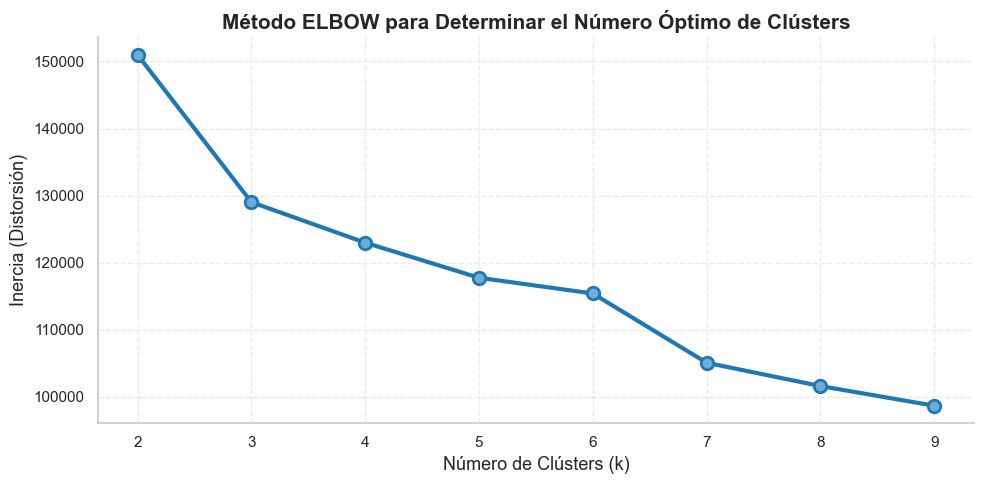

In [41]:
sns.set_style("whitegrid")
distortions = []
K_range = range(2, 10)

for k in K_range:
    kmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeanModel.fit(X_pca)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    K_range,
    distortions,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Inercia (Distorsión)", fontsize=13)
plt.title("Método ELBOW para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

segun esta grafica de elbow indica que el mejor k es 3 donde esta el punto de inflexion

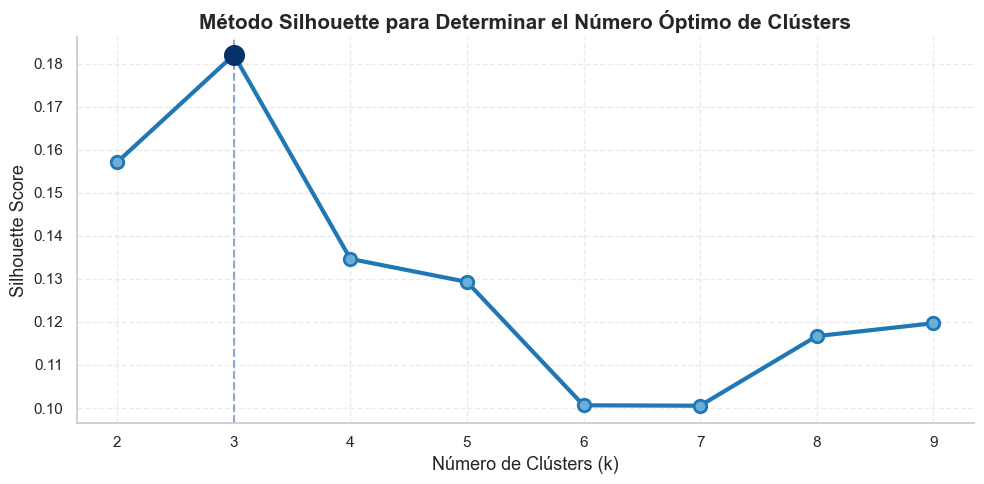

In [42]:
sns.set_style("whitegrid")

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_pca, kmeans.labels_, metric='euclidean')
    scores.append(score)

scores = np.array(scores)

best_k = list(K_range)[scores.argmax()]
best_score = scores.max()

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    list(K_range),
    scores,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

#esto es para resaltar el mejor k
plt.scatter(best_k, best_score, s=200, color="#08306b", zorder=3)
plt.axvline(best_k, linestyle="--", alpha=0.6)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Método Silhouette para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

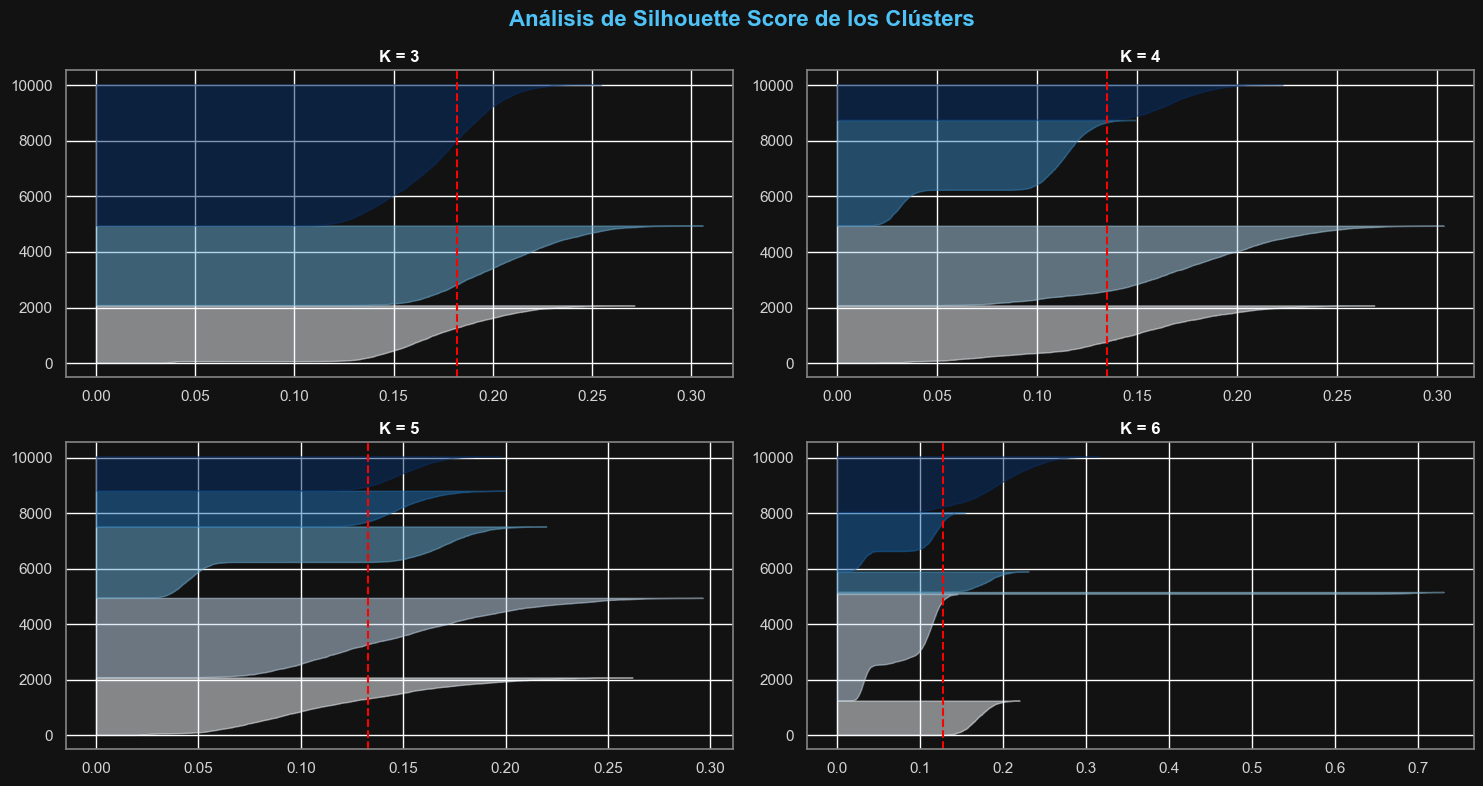

In [43]:
plt.style.use('dark_background')
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig.patch.set_facecolor('#121212') 
	
k_values = [3, 4, 5, 6]
	
for i, k in enumerate(k_values):
	km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
	    
	fila = i // 2
	columna = i % 2
	    
	ax[fila][columna].set_facecolor('#121212')
	    
	    # Al usar 'Blues' sobre fondo negro, los azules resaltarán muchísimo más
	visualizer = SilhouetteVisualizer(km, colors='Blues', ax=ax[fila][columna])
	visualizer.fit(X_pca)
	    
	ax[fila][columna].set_title(f"K = {k}", color="white", fontsize=12, weight="bold")
	    
	ax[fila][columna].tick_params(colors='lightgray')
	for spine in ax[fila][columna].spines.values():
	        spine.set_color('gray')
	
fig.suptitle("Análisis de Silhouette Score de los Clústers", color="#4fc3f7", fontsize=16, weight="bold")
	
plt.tight_layout()
plt.show()
	
plt.style.use('default')

In [44]:
k = 3

kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
etiquetas_pca = kmeans.fit_predict(X_pca) 


In [45]:
df['Cluster-pca'] = etiquetas_pca

In [49]:
resultados = df.groupby('Cluster-pca').mean(numeric_only=True)[['study_hours_per_day', 'sleep_hours', 'final_exam_score', 'attendance_percentage']]
display(resultados)

,study_hours_per_day,sleep_hours,final_exam_score,attendance_percentage
Cluster-pca,,,,
0,5.504002,6.516796,45.412629,66.830014
1,5.496393,6.502432,82.208118,73.499703
2,5.436976,6.501961,63.254552,70.294642


podemos ver que el cluster dos pertenece a las personas que mas notas sacan teniendo una media mas alta de atencion en clase la media de sueño es similar a los demás clusteres 

-------